# bulk RNA-seq analysis

#### 1. Dataset and Experimental Design

The experiment investigates how APOE genotype and induced ageing affect the transcriptional state of human brain organoids.

The experimental design consists of:
- 2 APOE genotypes: APOE3 and APOE4
- 3 treatment durations: CTRL, 10D, and 20D
- 3 biological replicates per genotype × treatment combination
- 18 samples in total

Main questions we want to answer-

1. Does APOE genotype affect gene expression at baseline?
2. How does 20D induced ageing affect APOE3 organoids?
3. How does 20D induced ageing affect APOE4 organoids?
4. Does the transcriptional response to 20D differ between APOE3 and APOE4?

Analytical considerations for organoid data

Because the data are derived from bulk brain organoids, transcriptional differences represent the aggregate expression of cells within each organoid. Therefore, observed changes may reflect both cell-intrinsic transcriptional regulation and differences in cellular composition.


In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.decomposition import PCA
from sklearn.metrics import pairwise_distances

from pydeseq2.dds import DeseqDataSet
from pydeseq2.ds import DeseqStats

In [2]:
BASE = "data"
OUT = os.path.join(BASE, "rna_challenge_analysis")
FIG = os.path.join(OUT, "figures")

os.makedirs(FIG, exist_ok=True)

In [3]:
counts = pd.read_csv(
    os.path.join(BASE, "counts.tsv"),
    sep="\t",
    index_col=0
)

meta = pd.read_csv(
    os.path.join(BASE, "RNAseq_challenge_metadata.csv")
).set_index("sample")

# metadata and count-matrix samples are in the same order
meta = meta.loc[counts.columns]

print("Counts:", counts.shape)
display(counts.head())

print("Metadata:", meta.shape)
display(meta)

Counts: (78691, 18)


,APOE3_CTRL_1,APOE3_CTRL_2,APOE3_CTRL_3,APOE3_AGED10D_1,APOE3_AGED10D_2,APOE3_AGED10D_3,APOE3_AGED20D_1,APOE3_AGED20D_2,APOE3_AGED20D_3,APOE4_CTRL_1,APOE4_CTRL_2,APOE4_CTRL_3,APOE4_AGED10D_1,APOE4_AGED10D_2,APOE4_AGED10D_3,APOE4_AGED20D_1,APOE4_AGED20D_2,APOE4_AGED20D_3
ENSG00000000003.17,773,753,752,392,683,465,406,303,364,808,811,813,531,735,552,732,827,775
ENSG00000000005.6,0,1,0,0,3,0,6,0,1,1,0,1,1,10,6,3,0,3
ENSG00000000419.15,862,895,931,967,1035,819,890,825,788,828,938,804,745,1218,917,1079,1344,1175
ENSG00000000457.15,717,649,653,605,698,618,633,601,569,747,691,691,642,600,619,590,704,700
ENSG00000000460.18,531,492,488,341,385,308,244,240,263,527,483,500,274,411,345,214,262,212


Metadata: (18, 5)


,genotype,condition,ageing_treatment_days,harvest_day,replicate
APOE3_CTRL_1,APOE3,CTRL,0,80,1
APOE3_CTRL_2,APOE3,CTRL,0,80,2
APOE3_CTRL_3,APOE3,CTRL,0,80,3
APOE3_AGED10D_1,APOE3,AGED,10,70,1
APOE3_AGED10D_2,APOE3,AGED,10,70,2
APOE3_AGED10D_3,APOE3,AGED,10,70,3
APOE3_AGED20D_1,APOE3,AGED,20,80,1
APOE3_AGED20D_2,APOE3,AGED,20,80,2
APOE3_AGED20D_3,APOE3,AGED,20,80,3
APOE4_CTRL_1,APOE4,CTRL,0,80,1


Dataset summary

The dataset contains 18 samples with gene-level expression counts. The metadata contain the APOE genotype, ageing treatment, treatment duration, harvest day, and biological replicate information.

#### 2. QC and preprocessing

Before investigating biological differences, I first assessed sequencing quality, library sizes, and the distribution of gene-level counts to identify potential technical problems or outlier samples.

Lowly expressed genes were filtered because they provide little statistical information and can increase noise in downstream analyses.

counts.tsv

- The counts data contains Ensembl gene IDs with version suffixes and 18 samples. 
- Filtering out genes with fewer than 10 counts in at least 3 samples to reduces noise from extremely sparse features.

In [4]:
keep=(counts>=10).sum(axis=1)>=3
c=counts.loc[keep]
lib=c.sum(axis=0)
cpm=c.div(lib,axis=1)*1e6
logcpm=np.log2(cpm+0.5)

print(f"Genes before filtering: {counts.shape[0]:,}")
print(f"Genes after filtering:  {c.shape[0]:,}")
print(f"Samples: {c.shape[1]}")
display(pd.DataFrame({"library_size":lib,"library_size_in_millions":lib/1e6}).describe())

Genes before filtering: 78,691
Genes after filtering:  29,414
Samples: 18


,library_size,library_size_in_millions
count,1.800000e+01,18.000000
mean,2.740249e+07,27.402491
std,2.031700e+06,2.031700
min,2.440568e+07,24.405680
25%,2.609345e+07,26.093448
50%,2.695932e+07,26.959315
75%,2.936277e+07,29.362771
max,3.053744e+07,30.537444


MultiQC general stats report

In [5]:
qc=pd.read_html(os.path.join(BASE,"multiqc_report.html"))[0]
display(qc)
qc.to_csv(os.path.join(OUT,"multiqc_general_stats.csv"),index=False)

,Sample Name,% Aligned,M Aligned,% Aligned.1,M Aligned.1,% Duplication,% > Q30,Mb Q30 bases,M Reads After Filtering,GC content,% PF,% Adapter
0,APOE3_AGED10D_1,31.3%,27.2,78.7%,68.3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,APOE3_AGED10D_1.pe,NaN,NaN,NaN,NaN,21.6%,97.6%,17023.4,173.6,43.5%,99.3%,3.3%
2,APOE3_AGED10D_2,31.0%,30.8,69.5%,69.1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,APOE3_AGED10D_2.pe,NaN,NaN,NaN,NaN,29.3%,97.7%,19527.1,198.9,43.3%,99.3%,3.3%
4,APOE3_AGED10D_3,31.1%,25.4,72.5%,59.2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,APOE3_AGED10D_3.pe,NaN,NaN,NaN,NaN,25.2%,97.6%,16029.0,163.4,43.5%,99.4%,3.4%
6,APOE3_AGED20D_1,30.6%,27.0,70.9%,62.6,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,APOE3_AGED20D_1.pe,NaN,NaN,NaN,NaN,26.9%,97.6%,17308.4,176.5,43.6%,99.3%,3.5%
8,APOE3_AGED20D_2,30.1%,25.4,70.0%,59.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,APOE3_AGED20D_2.pe,NaN,NaN,NaN,NaN,28.0%,97.6%,16510.3,168.4,43.6%,99.3%,3.4%


- Sequencing quality is consistent across samples. 

- More than 97% of bases are Q30 or higher, GC content is stable (~43–44%), adapter content is low (~2–4%), and sequencing depth is relatively comparable across samples. 

- Alignment rates shows greater variability (~65–80%), while duplication rates are around ~22–33%. 

- No sample showed multiple severely abnormal QC metrics, so no samples are excluded based on MultiQC alone.


Library Size

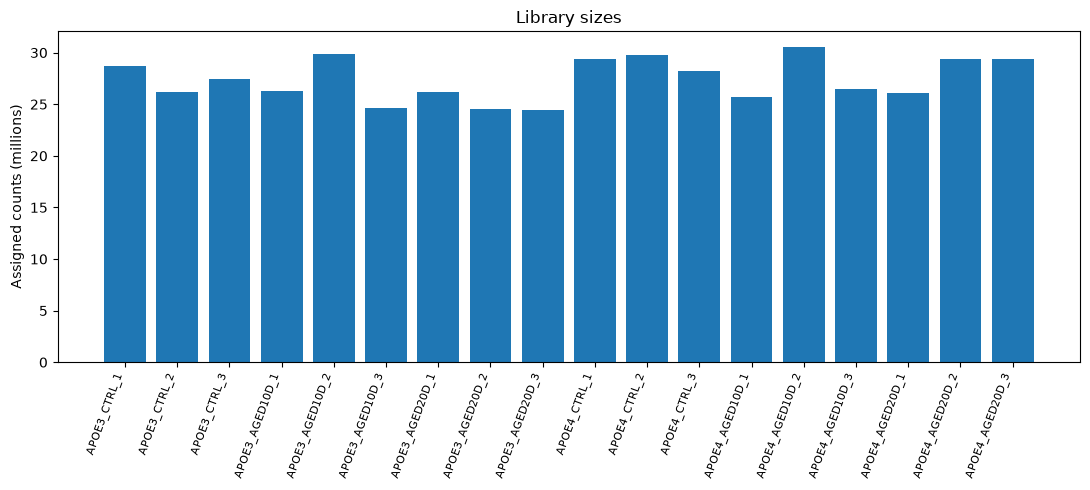

In [6]:
plt.figure(figsize=(11,5))
order=meta.sort_values(["genotype","ageing_treatment_days","replicate"]).index
plt.bar(np.arange(len(order)),lib[order]/1e6)
plt.xticks(np.arange(len(order)),order,rotation=70,ha="right",fontsize=8)
plt.ylabel("Assigned counts (millions)")
plt.title("Library sizes")
plt.tight_layout()
plt.show()

Library sizes are relatively consistent across samples, ranging from approximately 24.5 to 30.5 million assigned counts, with no obvious low-depth outliers.

In [7]:
zero_fraction = (counts == 0).mean().mean()

print(f"Overall proportion of zero counts: {zero_fraction:.2%}")

Overall proportion of zero counts: 44.49%


Approximately 44.5% of entries in the original gene-level count matrix were zero, reflecting the sparsity of gene-level RNA-seq measurements. Low-count features were subsequently filtered before downstream analysis.


**QC Summary**

The sequencing and library-level QC metrics were broadly consistent across samples, and no sample showed multiple severely abnormal QC metrics. Therefore, no samples were excluded based on the available QC information.

After filtering low-count genes, 29,414 genes remained for downstream analysis.

#### 3. Exploratory analysis

After confirming that the sequencing data were of sufficient quality, I next examined the overall structure of the expression data. Because organoid models can exhibit biological variability between replicates.

The goal was to determine:
- whether biological replicates were reproducible,
- whether samples separated according to APOE genotype or treatment,
- and whether any samples behaved as potential outliers.

Log-transformed CPM values were used for exploratory analyses such as PCA, sample correlations, clustering and heatmaps. Raw filtered counts were retained for DESeq2 differential expression analysis.

Explained variance: [0.368 0.272 0.132]


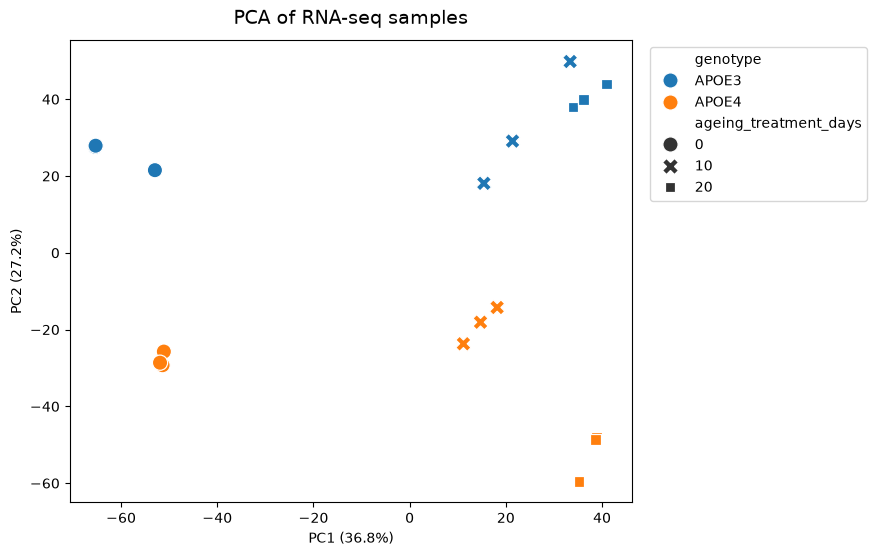

In [8]:
pca = PCA(n_components=5).fit(logcpm.T)

pc = pca.transform(logcpm.T)

pca_df = pd.DataFrame(
    pc[:, :3],
    index=meta.index,
    columns=["PC1", "PC2", "PC3"]
).join(meta)

print(
    "Explained variance:",
    np.round(pca.explained_variance_ratio_[:3], 3)
)

# PCA plot
fig, ax = plt.subplots(figsize=(9, 6))

sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="genotype",
    style="ageing_treatment_days",
    s=120,
    ax=ax
)

ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")

ax.set_title("PCA of RNA-seq samples", fontsize=14, pad=12)

# Legend outside the plotting area
ax.legend(
    title=None,
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    frameon=True
)

# Leave room for the external legend
fig.subplots_adjust(right=0.75)

plt.show()

PCA Interpretation

PC1 and PC2 together explained 64.0% of the total variation. Samples showed clear separation by APOE genotype and treatment condition, while biological replicates generally clustered together.

This suggests that genotype and treatment are major sources of transcriptional variation, while replicate variability is relatively limited.

The separation between 10D and CTRL should be interpreted cautiously because the 10D samples were harvested at day 70, whereas the CTRL samples were harvested at day 80. Therefore, treatment and harvest day cannot be separated for this comparison.


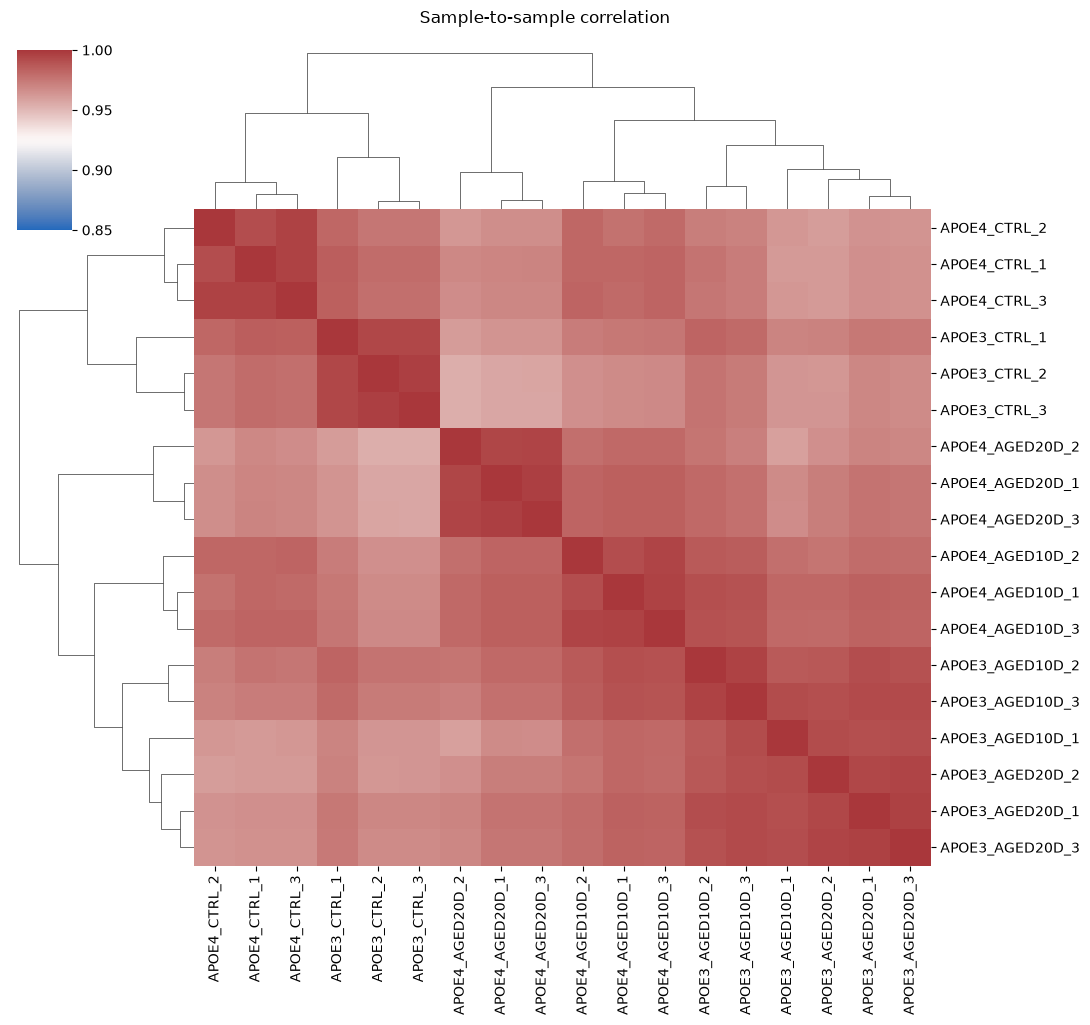

In [9]:
# Sample-to-sample Pearson correlation
corr = logcpm.corr(method="pearson")

sns.clustermap(
    corr,
    cmap="vlag",
    vmin=0.85,
    vmax=1,
    figsize=(11, 10),
    row_cluster=True,
    col_cluster=True
)

plt.suptitle("Sample-to-sample correlation", y=1.02)

plt.show()

In [10]:
print("Minimum correlation:", corr.min().min())
print("Maximum correlation:", corr.max().max())

Minimum correlation: 0.9540395716014499
Maximum correlation: 1.0


Correlation Interpretation

Sample correlations were high across all samples (r = 0.95–1.00), indicating strong overall similarity between samples and no obvious sample-level outliers.

In [11]:
D = pairwise_distances(logcpm.T, metric="euclidean")

groups = meta.genotype + "_" + meta.ageing_treatment_days.astype(str)

within = []
between = []

for i in range(len(meta)):
    for j in range(i + 1, len(meta)):
        if groups.iloc[i] == groups.iloc[j]:
            within.append(D[i, j])
        else:
            between.append(D[i, j])

print("Median within-condition distance:", round(np.median(within), 2))
print("Median between-condition distance:", round(np.median(between), 2))

Median within-condition distance: 45.29
Median between-condition distance: 101.23


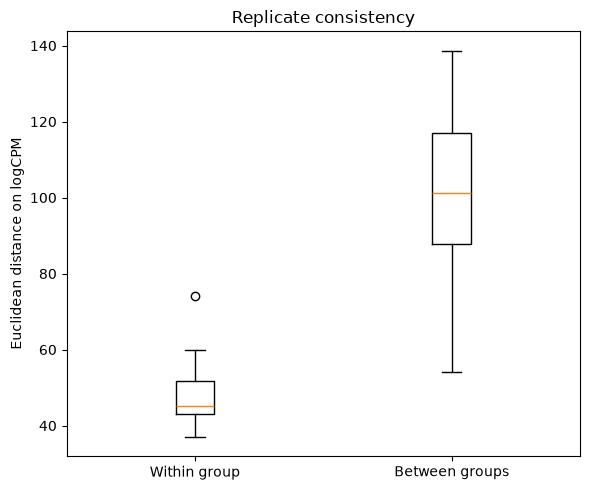

In [12]:
plt.figure(figsize=(6, 5))

plt.boxplot(
    [within, between],
    tick_labels=["Within group", "Between groups"]
)

plt.ylabel("Euclidean distance on logCPM")
plt.title("Replicate consistency")

plt.tight_layout()
plt.show()

Distance Interpretation

Within-group samples had lower expression distances than between-group samples (median 45.29 vs 101.23), supporting good replicate consistency and separation between experimental groups.

Exploratory analysis summary

Overall, the exploratory analysis showed reproducible biological replicates, high sample-to-sample correlations, and separation between experimental groups. 
This supported proceeding to differential expression analysis to identify the genes underlying these transcriptional differences.

#### 4. Differential Expression

The exploratory analysis showed that genotype and treatment contribute substantially to transcriptional variation. I therefore next identified individual genes associated with these experimental factors.

DESeq2 was used because the input consists of gene-level count data and the method models count variability between biological replicates.

Genes were considered differentially expressed when FDR < 0.05 and |log2FC| ≥ 1.

Four analyses were performed:

1. To determine whether APOE genotype is associated with different transcriptional states independently of ageing treatment, I compared APOE4 CTRL with APOE3 CTRL samples.
2. I next asked how the ageing treatment changes gene expression in APOE3 organoids. I compared APOE3 20D with APOE3 CTRL.
3. The same comparison was performed in APOE4 organoids to determine whether the transcriptional response to 20D is similar or different in the two genotypes.
4. Comparing the two ageing responses separately can show that both genotypes respond to 20D, but it does not formally test whether their responses are different. I therefore fitted a genotype × treatment interaction model using CTRL and 20D samples. This tests whether the effect of 20D differs between APOE3 and APOE4.

The 10D samples were excluded from this analysis because 10D is completely confounded with harvest day.


In [13]:
# PyDESeq2 expects samples as rows and genes as columns
counts_deseq = c.T.copy()

# DESeq2 requires integer count values
counts_deseq = counts_deseq.round().astype(int)

# Check dimensions and sample alignment
print("Count matrix:", counts_deseq.shape)
print("Samples match metadata:", counts_deseq.index.equals(meta.index))

Count matrix: (18, 29414)
Samples match metadata: True


In [14]:
import mygene

mg = mygene.MyGeneInfo()

gene_ids = (
    counts_deseq.columns
    .str.replace(r"\..*$", "", regex=True)
    .tolist()
)

annotation = mg.querymany(
    gene_ids,
    scopes="ensembl.gene",
    fields="symbol",
    species="human",
    as_dataframe=True
)

annotation = annotation[["symbol"]]
annotation.index.name = "ensembl_id"

annotation.head()

16 input query terms found dup hits:	[('ENSG00000117262', 2), ('ENSG00000188092', 2), ('ENSG00000226519', 2), ('ENSG00000227110', 2), ('E
11 input query terms found no hit:	['ENSG00000177133', 'ENSG00000260160', 'ENSG00000261114', 'ENSG00000261270', 'ENSG00000272529', 'ENS


,symbol
ensembl_id,
ENSG00000000003,TSPAN6
ENSG00000000419,DPM1
ENSG00000000457,SCYL3
ENSG00000000460,FIRRM
ENSG00000000938,FGR


In [15]:
def run_genotype_deseq2(
    counts,
    metadata,
    treatment_days
):
    """
    Runs DESeq2 to compare APOE4 and APOE3
    within a specific treatment condition.

    Inputs:
    - counts: count matrix with samples as rows and genes as columns
    - metadata: sample metadata
    - treatment_days: treatment duration to analyse (0 or 20)

    Output:
    - DESeq2 results table
    """

    # Select samples from the requested treatment condition
    samples = metadata.index[
        metadata["ageing_treatment_days"] == treatment_days
    ]

    counts_subset = counts.loc[samples].copy()
    metadata_subset = metadata.loc[samples].copy()

    # Set APOE3 as the reference genotype
    metadata_subset["genotype"] = pd.Categorical(
        metadata_subset["genotype"],
        categories=["APOE3", "APOE4"]
    )

    # Create DESeq2 dataset
    dds = DeseqDataSet(
        counts=counts_subset,
        metadata=metadata_subset,
        design_factors="genotype",
        refit_cooks=True
    )

    # Run DESeq2
    dds.deseq2()

    # Test APOE4 vs APOE3
    stats = DeseqStats(
        dds,
        contrast=["genotype", "APOE4", "APOE3"]
    )

    stats.summary()

    # Return results
    results = stats.results_df.copy()

    return results

In [16]:
def run_ageing_deseq2(
    counts,
    metadata,
    genotype
):
    """
    Runs DESeq2 to compare 20D vs CTRL
    within a specific APOE genotype.

    Inputs:
    - counts: count matrix with samples as rows and genes as columns
    - metadata: sample metadata
    - genotype: APOE genotype to analyse ("APOE3" or "APOE4")

    Output:
    - DESeq2 results table
    """

    samples = metadata.index[
        (metadata["genotype"] == genotype) &
        (metadata["ageing_treatment_days"].isin([0, 20]))
    ]

    counts_subset = counts.loc[samples].copy()
    metadata_subset = metadata.loc[samples].copy()

    metadata_subset["age20"] = (
        metadata_subset["ageing_treatment_days"]
        .map({0: "CTRL", 20: "AGED20D"})
    )

    metadata_subset["age20"] = pd.Categorical(
        metadata_subset["age20"],
        categories=["CTRL", "AGED20D"]
    )

    dds = DeseqDataSet(
        counts=counts_subset,
        metadata=metadata_subset,
        design_factors="age20",
        refit_cooks=True
    )

    dds.deseq2()

    stats = DeseqStats(
        dds,
        contrast=["age20", "AGED20D", "CTRL"]
    )

    stats.summary()

    return stats.results_df.copy()

In [17]:
def run_genotype_20d_interaction(
    counts,
    metadata
):
    """
    Tests whether the APOE4 vs APOE3 difference
    changes after 20D treatment.

    Uses only CTRL and 20D samples.

    Inputs:
    - counts: count matrix with samples as rows and genes as columns
    - metadata: sample metadata

    Output:
    - DESeq2 interaction results table
    """

    # Select CTRL and 20D samples
    samples = metadata.index[
        metadata["ageing_treatment_days"].isin([0, 20])
    ]

    counts_subset = counts.loc[samples].copy()
    metadata_subset = metadata.loc[samples].copy()

    # Create treatment variable
    metadata_subset["age20"] = (
        metadata_subset["ageing_treatment_days"]
        .map({
            0: "CTRL",
            20: "AGED20D"
        })
    )

    # Set reference levels
    metadata_subset["genotype"] = pd.Categorical(
        metadata_subset["genotype"],
        categories=["APOE3", "APOE4"]
    )

    metadata_subset["age20"] = pd.Categorical(
        metadata_subset["age20"],
        categories=["CTRL", "AGED20D"]
    )

    # Create DESeq2 dataset with interaction model
    dds = DeseqDataSet(
        counts=counts_subset,
        metadata=metadata_subset,
        design="~ genotype * age20",
        refit_cooks=True
    )

    # Run DESeq2
    dds.deseq2()

    # Get the interaction coefficient
    design_columns = dds.obsm["design_matrix"].columns

    interaction_name = (
        "genotype[T.APOE4]:age20[T.AGED20D]"
    )

    interaction_contrast = np.zeros(
        len(design_columns)
    )

    interaction_contrast[
        list(design_columns).index(interaction_name)
    ] = 1

    # Test the interaction
    stats = DeseqStats(
        dds,
        contrast=interaction_contrast
    )

    stats.summary()

    # Return results
    results = stats.results_df.copy()

    return results

In [18]:
def summarize_de(
    results,
    title,
    annotation=None,
    top_n=20
):
    """
    Summarizes DESeq2 results.

    DE genes are defined as:
    - adjusted p-value < 0.05
    - |log2 fold change| >= 1

    Inputs:
    - results: DESeq2 results table
    - title: name of the comparison
    - annotation: gene symbol annotation table
    - top_n: number of top DE genes to display

    Output:
    - Dictionary containing all DE results,
      significant genes, up/down genes, and top genes.
    """

    # Remove genes without statistical results
    results = results.dropna(
        subset=["padj", "log2FoldChange"]
    ).copy()

    # Identify significant DE genes
    results["DE"] = (
        (results["padj"] < 0.05) &
        (results["log2FoldChange"].abs() >= 1)
    )

    # Identify upregulated genes
    up = results[
        (results["padj"] < 0.05) &
        (results["log2FoldChange"] >= 1)
    ].copy()

    # Identify downregulated genes
    down = results[
        (results["padj"] < 0.05) &
        (results["log2FoldChange"] <= -1)
    ].copy()

    # Keep significant DE genes
    de = results[results["DE"]].copy()

    # Print summary
    print(f"\n{title}")
    print("-" * len(title))
    print("DE genes:", len(de))
    print("Upregulated:", len(up))
    print("Downregulated:", len(down))

    # Select top genes
    top = (
        de.sort_values("padj")
        .head(top_n)
        .copy()
    )

    # Remove Ensembl version numbers
    top["ensembl_id"] = (
        top.index
        .str.replace(r"\..*$", "", regex=True)
    )

    # Add gene symbols
    if annotation is not None:

        symbols = annotation["symbol"].to_dict()

        top["symbol"] = [
            symbols.get(g, g)
            if pd.notna(symbols.get(g))
            else g
            for g in top["ensembl_id"]
        ]

    else:
        top["symbol"] = top["ensembl_id"]

    # Select columns for display
    top_table = top[
        [
            "symbol",
            "ensembl_id",
            "baseMean",
            "log2FoldChange",
            "pvalue",
            "padj"
        ]
    ]

    display(top_table)

    return {
        "all": results,
        "DE": de,
        "up": up,
        "down": down,
        "top": top_table
    }

In [19]:
def plot_volcano(
    results,
    title
):
    """
    Creates a volcano plot from DESeq2 results.

    Inputs:
    - results: summarized DESeq2 results containing
      log2FoldChange, padj, and DE
    - title: plot title
    """

    results = results.copy()

    # Convert adjusted p-value to -log10 scale
    results["neg_log10_padj"] = -np.log10(
        results["padj"].clip(lower=1e-300)
    )

    # Plot genes
    plt.figure(figsize=(8, 6))

    sns.scatterplot(
        data=results,
        x="log2FoldChange",
        y="neg_log10_padj",
        hue="DE",
        palette={
            True: "red",
            False: "lightgray"
        },
        alpha=0.6,
        s=20,
        legend=False
    )

    # Add fold-change thresholds
    plt.axvline(
        1,
        linestyle="--",
        color="black"
    )

    plt.axvline(
        -1,
        linestyle="--",
        color="black"
    )

    # Add significance threshold
    plt.axhline(
        -np.log10(0.05),
        linestyle="--",
        color="black"
    )

    plt.xlabel("log2 fold change")
    plt.ylabel("-log10 adjusted p-value")
    plt.title(title)

    plt.tight_layout()
    plt.show()

In [20]:
# Baseline: APOE4 CTRL vs APOE3 CTRL
res_ctrl = run_genotype_deseq2(
    counts_deseq,
    meta,
    treatment_days=0
)

Using None as control genes, passed at DeseqDataSet initialization


/var/folders/6f/wh6m6kqx1sn0fxgvj7fww4wm0000gn/T/ipykernel_83508/4240297023.py:34: DeprecationWarning: design_factors is deprecated and will soon be removed.Please consider providing a formulaic formula using the design argumentinstead.
  dds = DeseqDataSet(
Fitting size factors...
... done in 0.01 seconds.

Fitting dispersions...
... done in 4.59 seconds.

Fitting dispersion trend curve...
... done in 0.59 seconds.

Fitting MAP dispersions...
... done in 4.94 seconds.

Fitting LFCs...
... done in 3.13 seconds.

Calculating cook's distance...
... done in 0.02 seconds.

Replacing 0 outlier genes.

Running Wald tests...


Log2 fold change & Wald test p-value: genotype APOE4 vs APOE3
                      baseMean  log2FoldChange     lfcSE      stat    pvalue  \
ENSG00000000003.17  781.482923        0.000460  0.101119  0.004552  0.996368   
ENSG00000000419.15  873.844527       -0.162939  0.108206 -1.505821  0.132113   
ENSG00000000457.15  687.938057       -0.015199  0.105429 -0.144160  0.885374   
ENSG00000000460.18  501.655755       -0.092868  0.114597 -0.810388  0.417717   
ENSG00000000938.14   14.899013        1.314247  0.511674  2.568522  0.010213   
...                        ...             ...       ...       ...       ...   
ENSG00000310560.2   575.620063       -0.005128  0.108227 -0.047385  0.962206   
ENSG00000310566.1     8.411356       -0.803628  0.670122 -1.199225  0.230440   
ENSG00000310576.1    77.699030       -0.037795  0.227148 -0.166388  0.867851   
ENSG00000310585.1    49.299157       -0.368416  0.324375 -1.135771  0.256052   
ENSG00000310592.1    11.277278       -0.258690  0.539029 -

... done in 1.24 seconds.



In [21]:
# APOE3 CTRL vs 20D
res_age_apoe3 = run_ageing_deseq2(
    counts_deseq,
    meta,
    "APOE3"
)

Using None as control genes, passed at DeseqDataSet initialization


/var/folders/6f/wh6m6kqx1sn0fxgvj7fww4wm0000gn/T/ipykernel_83508/2119639390.py:37: DeprecationWarning: design_factors is deprecated and will soon be removed.Please consider providing a formulaic formula using the design argumentinstead.
  dds = DeseqDataSet(
Fitting size factors...
... done in 0.01 seconds.

Fitting dispersions...
... done in 4.45 seconds.

Fitting dispersion trend curve...
... done in 0.47 seconds.

Fitting MAP dispersions...
... done in 4.94 seconds.

Fitting LFCs...
... done in 5.67 seconds.

Calculating cook's distance...
... done in 0.02 seconds.

Replacing 0 outlier genes.

Running Wald tests...


Log2 fold change & Wald test p-value: age20 AGED20D vs CTRL
                      baseMean  log2FoldChange     lfcSE      stat  \
ENSG00000000003.17  549.704421       -1.021476  0.115296 -8.859574   
ENSG00000000419.15  858.761491       -0.038787  0.097521 -0.397729   
ENSG00000000457.15  631.105125       -0.095160  0.094011 -1.012228   
ENSG00000000460.18  370.702400       -0.947201  0.117412 -8.067356   
ENSG00000000938.14    7.977770       -0.031308  0.723107 -0.043297   
...                        ...             ...       ...       ...   
ENSG00000310560.2   500.633506       -0.248096  0.106265 -2.334690   
ENSG00000310566.1     8.956575       -0.364667  0.628082 -0.580605   
ENSG00000310576.1    54.263506       -1.116886  0.265550 -4.205928   
ENSG00000310585.1    47.813816       -0.276208  0.333112 -0.829175   
ENSG00000310592.1    16.083525        0.830137  0.459020  1.808500   

                          pvalue          padj  
ENSG00000000003.17  8.032052e-19  1.781468e-17  
E

... done in 1.46 seconds.



In [22]:
# APOE4 CTRL vs 20D
res_age_apoe4 = run_ageing_deseq2(
    counts_deseq,
    meta,
    "APOE4"
)

Using None as control genes, passed at DeseqDataSet initialization


/var/folders/6f/wh6m6kqx1sn0fxgvj7fww4wm0000gn/T/ipykernel_83508/2119639390.py:37: DeprecationWarning: design_factors is deprecated and will soon be removed.Please consider providing a formulaic formula using the design argumentinstead.
  dds = DeseqDataSet(
Fitting size factors...
... done in 0.01 seconds.

Fitting dispersions...
... done in 4.87 seconds.

Fitting dispersion trend curve...
... done in 0.53 seconds.

Fitting MAP dispersions...
... done in 4.96 seconds.

Fitting LFCs...
... done in 3.14 seconds.

Calculating cook's distance...
... done in 0.01 seconds.

Replacing 0 outlier genes.

Running Wald tests...
... done in 1.50 seconds.



Log2 fold change & Wald test p-value: age20 AGED20D vs CTRL
                       baseMean  log2FoldChange     lfcSE      stat  \
ENSG00000000003.17   788.326182        0.072056  0.093932  0.767105   
ENSG00000000419.15  1027.343042        0.617310  0.097221  6.349579   
ENSG00000000457.15   680.918364        0.034072  0.100178  0.340113   
ENSG00000000460.18   357.860087       -1.003394  0.130986 -7.660338   
ENSG00000000938.14    13.060937       -2.008360  0.584408 -3.436574   
...                         ...             ...       ...       ...   
ENSG00000310560.2    549.879753       -0.080687  0.105174 -0.767176   
ENSG00000310566.1      8.580268        0.886287  0.665602  1.331556   
ENSG00000310576.1     82.934688        0.264622  0.215398  1.228523   
ENSG00000310585.1     51.447446        0.523342  0.269261  1.943622   
ENSG00000310592.1     13.269478        0.695665  0.539052  1.290534   

                          pvalue          padj  
ENSG00000000003.17  4.430192e-01  5.65

In [23]:
# Genotype × 20D interaction
res_int = run_genotype_20d_interaction(
    counts_deseq,
    meta
)

Using None as control genes, passed at DeseqDataSet initialization


Fitting size factors...
... done in 0.02 seconds.

Fitting dispersions...
... done in 4.53 seconds.

Fitting dispersion trend curve...
... done in 0.48 seconds.

Fitting MAP dispersions...
... done in 5.41 seconds.

Fitting LFCs...
... done in 3.66 seconds.

Calculating cook's distance...
... done in 0.02 seconds.

Replacing 0 outlier genes.

Running Wald tests...
... done in 1.07 seconds.



Log2 fold change & Wald test p-value, contrast vector: [0. 0. 0. 1.]
                      baseMean  log2FoldChange     lfcSE      stat  \
ENSG00000000003.17  667.096294        1.091397  0.128854  8.470021   
ENSG00000000419.15  942.178632        0.654301  0.124304  5.263700   
ENSG00000000457.15  656.190777        0.128037  0.110741  1.156187   
ENSG00000000460.18  364.821123       -0.057798  0.153739 -0.375952   
ENSG00000000938.14   10.476738       -1.973293  0.832422 -2.370544   
...                        ...             ...       ...       ...   
ENSG00000310560.2   525.303866        0.165904  0.124574  1.331769   
ENSG00000310566.1     8.783657        1.249314  0.804332  1.553232   
ENSG00000310576.1    68.352062        1.378759  0.290501  4.746146   
ENSG00000310585.1    49.640165        0.795282  0.408370  1.947458   
ENSG00000310592.1    14.723475       -0.138554  0.610489 -0.226955   

                          pvalue          padj  
ENSG00000000003.17  2.453479e-17  1.93996

In [24]:
ctrl_results = summarize_de(
    res_ctrl,
    "APOE4 vs APOE3 — CTRL",
    annotation=annotation
)

age_apoe3_results = summarize_de(
    res_age_apoe3,
    "APOE3 — 20D vs CTRL",
    annotation=annotation
)

age_apoe4_results = summarize_de(
    res_age_apoe4,
    "APOE4 — 20D vs CTRL",
    annotation=annotation
)

int_results = summarize_de(
    res_int,
    "Genotype × 20D interaction",
    annotation=annotation
)


APOE4 vs APOE3 — CTRL
---------------------
DE genes: 1984
Upregulated: 1308
Downregulated: 676


,symbol,ensembl_id,baseMean,log2FoldChange,pvalue,padj
ENSG00000136352.20,NKX2-1,ENSG00000136352,1728.088699,-2.714995,9.346595e-174,2.695278e-169
ENSG00000269993.2,ENSG00000269993,ENSG00000269993,863.323363,-3.862747,6.773817e-151,9.766828e-147
ENSG00000245680.12,ZNF585B,ENSG00000245680,547.341935,3.362491,7.387870e-128,7.101466e-124
ENSG00000291080.2,ZNF252P,ENSG00000291080,524.209726,3.472567,1.559634e-120,1.124379e-116
ENSG00000242512.10,LINC01206,ENSG00000242512,720.037623,-4.485950,1.556556e-115,8.977279e-112
ENSG00000176971.4,FIBIN,ENSG00000176971,399.699914,3.588876,6.601490e-96,3.172786e-92
ENSG00000156925.13,ZIC3,ENSG00000156925,520.982178,-5.683513,9.595107e-96,3.952773e-92
ENSG00000132530.18,XAF1,ENSG00000132530,1076.105316,3.932287,1.259396e-94,4.539652e-91
ENSG00000262655.5,SPON1,ENSG00000262655,9627.215129,1.774057,6.456307e-94,2.068672e-90
ENSG00000102195.10,GPR50,ENSG00000102195,1232.089683,-3.750574,3.442896e-93,9.928279e-90



APOE3 — 20D vs CTRL
-------------------
DE genes: 4503
Upregulated: 2310
Downregulated: 2193


,symbol,ensembl_id,baseMean,log2FoldChange,pvalue,padj
ENSG00000125462.21,MIR9-1HG,ENSG00000125462,5328.414791,-3.032071,0.000000e+00,0.000000e+00
ENSG00000068078.21,FGFR3,ENSG00000068078,1265.315611,-4.008013,2.055317e-273,3.022343e-269
ENSG00000132692.20,BCAN,ENSG00000132692,1118.809650,-4.596706,2.421082e-231,2.373467e-227
ENSG00000168298.7,H1-4,ENSG00000168298,2798.568751,-2.871186,7.990256e-203,5.874836e-199
ENSG00000187837.5,H1-2,ENSG00000187837,1381.739080,-4.407124,1.239197e-188,7.288958e-185
ENSG00000169245.6,CXCL10,ENSG00000169245,1029.028764,-4.073933,1.907937e-188,9.352069e-185
ENSG00000255571.10,MIR9-3HG,ENSG00000255571,947.027819,-3.528867,7.521555e-182,3.160128e-178
ENSG00000270882.3,H4C14,ENSG00000270882,1628.506085,-2.836593,2.018576e-170,7.420791e-167
ENSG00000270276.3,H4C15,ENSG00000270276,1625.660408,-2.833713,3.480570e-169,1.137373e-165
ENSG00000184985.17,SORCS2,ENSG00000184985,1061.031630,-2.789727,1.977174e-156,5.814869e-153



APOE4 — 20D vs CTRL
-------------------
DE genes: 4895
Upregulated: 2501
Downregulated: 2394


,symbol,ensembl_id,baseMean,log2FoldChange,pvalue,padj
ENSG00000115414.22,FN1,ENSG00000115414,31742.707417,3.929090,0.000000e+00,0.000000e+00
ENSG00000139278.10,GLIPR1,ENSG00000139278,2040.067908,4.030866,1.770219e-261,2.603284e-257
ENSG00000164176.14,EDIL3,ENSG00000164176,5339.719215,2.547121,1.177605e-247,1.154524e-243
ENSG00000168298.7,H1-4,ENSG00000168298,2101.844455,-2.751060,1.426021e-238,1.048553e-234
ENSG00000132692.20,BCAN,ENSG00000132692,1124.498610,-4.832942,5.745594e-193,3.379788e-189
ENSG00000113916.18,BCL6,ENSG00000113916,3048.151100,2.263014,9.078833e-192,4.450444e-188
ENSG00000111057.12,KRT18,ENSG00000111057,823.043591,3.560652,5.851195e-179,2.458505e-175
ENSG00000068078.21,FGFR3,ENSG00000068078,2084.576650,-3.753693,1.915038e-177,7.040637e-174
ENSG00000170893.4,TRH,ENSG00000170893,551.724163,3.416245,2.181876e-157,7.130371e-154
ENSG00000139793.22,MBNL2,ENSG00000139793,3112.136771,2.115032,1.258136e-156,3.700429e-153



Genotype × 20D interaction
--------------------------
DE genes: 3548
Upregulated: 1778
Downregulated: 1770


,symbol,ensembl_id,baseMean,log2FoldChange,pvalue,padj
ENSG00000171444.19,MCC,ENSG00000171444,1264.581039,1.768532,1.939575e-70,5.705066e-66
ENSG00000132002.10,DNAJB1,ENSG00000132002,2428.676113,1.449164,8.881182e-70,1.306155e-65
ENSG00000058335.16,RASGRF1,ENSG00000058335,624.628276,-2.837799,2.959365e-67,2.901559e-63
ENSG00000139793.22,MBNL2,ENSG00000139793,2182.530046,2.049838,8.747181e-63,6.432239e-59
ENSG00000124225.16,PMEPA1,ENSG00000124225,1678.579477,2.402899,7.014307e-60,4.126377e-56
ENSG00000153707.21,PTPRD,ENSG00000153707,6387.232652,-1.258660,7.983700e-59,3.913876e-55
ENSG00000261150.3,EPPK1,ENSG00000261150,3580.674159,1.477382,5.170726e-57,2.172739e-53
ENSG00000134363.13,FST,ENSG00000134363,308.632001,3.339825,6.225468e-55,2.288949e-51
ENSG00000183395.5,PMCH,ENSG00000183395,488.843705,4.535688,1.704355e-50,5.570209e-47
ENSG00000157388.21,CACNA1D,ENSG00000157388,1398.732338,-1.436387,1.015297e-49,2.986394e-46


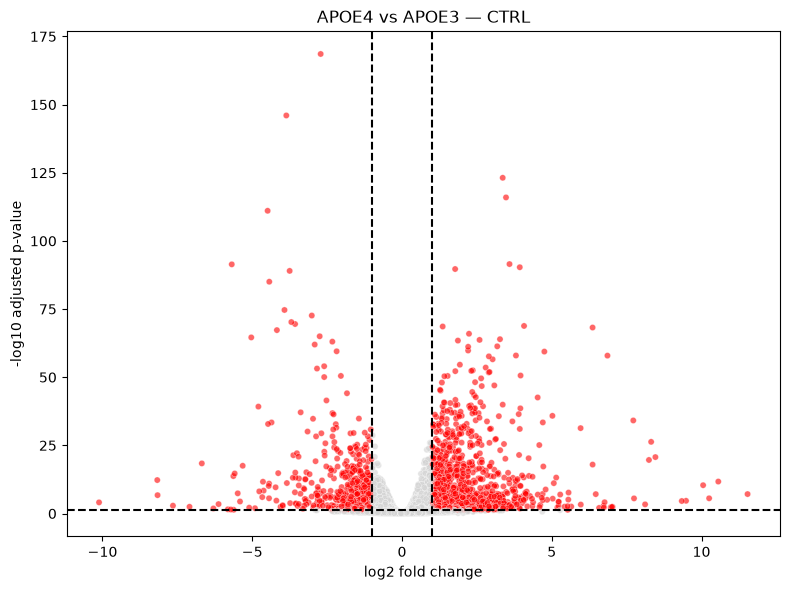

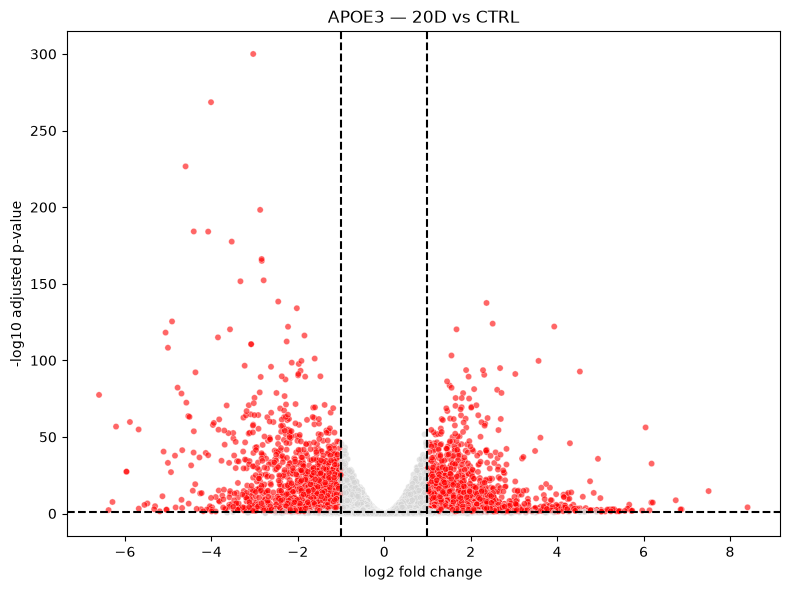

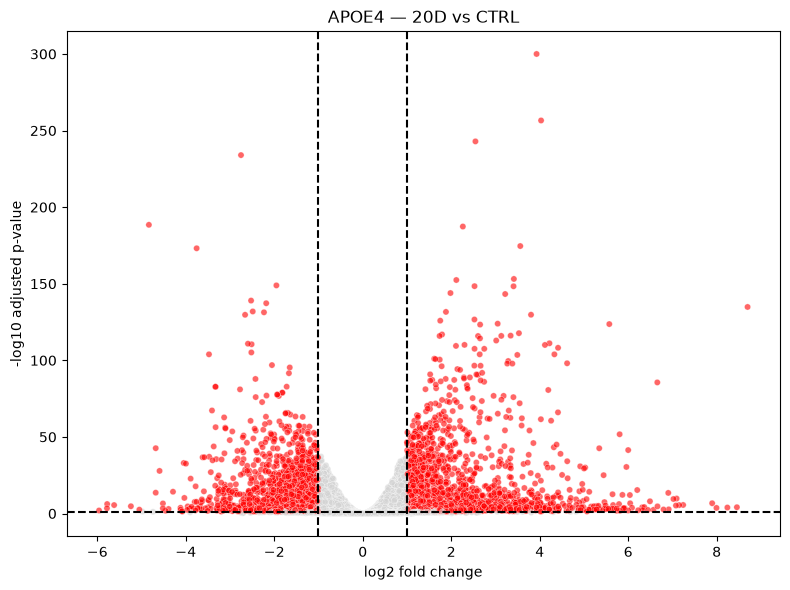

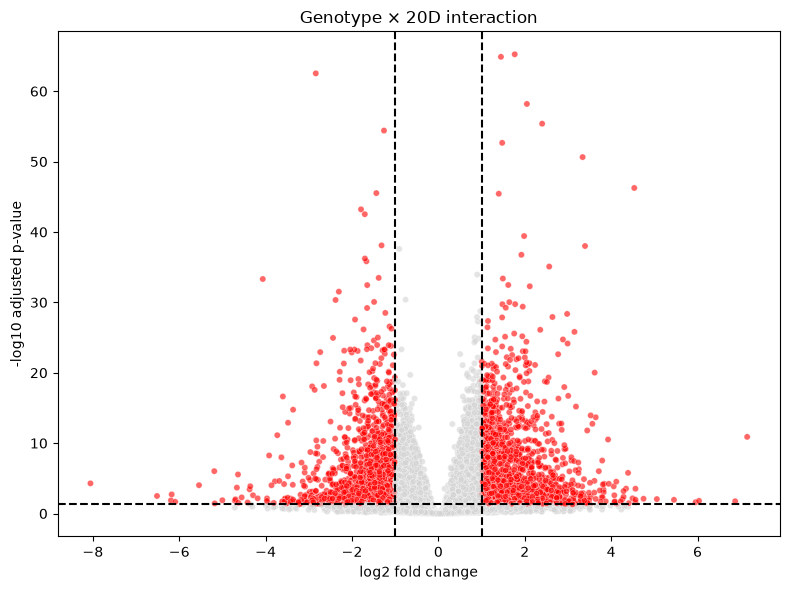

In [25]:
# Volcano plots
plot_volcano(
    ctrl_results["all"],
    "APOE4 vs APOE3 — CTRL"
)

plot_volcano(
    age_apoe3_results["all"],
    "APOE3 — 20D vs CTRL"
)
plot_volcano(
    age_apoe4_results["all"],
    "APOE4 — 20D vs CTRL"
)

plot_volcano(
    int_results["all"],
    "Genotype × 20D interaction"
)


DE Results

| Comparison                 |  DE genes | Positive / Up | Negative / Down |
| -------------------------- | --------: | ------------: | --------------: |
| APOE4 vs APOE3 — CTRL      | **1,984** |         1,308 |             676 |
| APOE3 — 20D vs CTRL    | **4,503** |         2,310 |           2,193 |
| APOE4 — 20D vs CTRL    | **4,895** |         2,501 |           2,394 |
| Genotype × 20D interaction | **3,548** |         1,778 |           1,770 |



* At baseline, APOE4 and APOE3 organoids showed substantial transcriptional differences, with 1,984 genes meeting the predefined DE criteria.

* Both genotypes also showed extensive transcriptional changes following 20D treatment, with 4,503 DE genes in APOE3 and 4,895 DE genes in APOE4.

* The genotype × 20D interaction identified 3,548 genes for which the APOE4–APOE3 expression difference changed following 20D treatment. This indicates that the transcriptional response to 20D differs between the two APOE genotypes.

Heatmap

After identifying differentially expressed genes, I examined the expression patterns of the top DE genes across all biological replicates.

This provides a visual assessment of whether the statistically identified genes show consistent expression patterns within experimental groups.

In [26]:
def plot_top_genes_heatmap(de_results, title):
    
    top_genes = (
        de_results["DE"]
        .sort_values("padj")
        .head(20)
        .index
    )

    top_genes_clean = (
        top_genes
        .str.replace(r"\..*$", "", regex=True)
    )

    heatmap_data = logcpm.loc[
        logcpm.index.str.replace(r"\..*$", "", regex=True)
        .isin(top_genes_clean)
    ].copy()

    heatmap_data.index = (
        heatmap_data.index
        .str.replace(r"\..*$", "", regex=True)
    )

    heatmap_data = heatmap_data.loc[top_genes_clean]

    heatmap_z = heatmap_data.sub(
        heatmap_data.mean(axis=1), axis=0
    ).div(
        heatmap_data.std(axis=1), axis=0
    )

    heatmap_z.columns = [
        x.replace("APOE3_", "E3_")
         .replace("APOE4_", "E4_")
         .replace("AGED10D", "10D")
         .replace("AGED20D", "20D")
        for x in heatmap_z.columns
    ]

    plt.figure(figsize=(12, 8))

    sns.heatmap(
        heatmap_z,
        cmap="vlag",
        center=0,
        xticklabels=True,
        yticklabels=True
    )

    plt.title(title)
    plt.xlabel("Samples")
    plt.ylabel("Genes")
    plt.xticks(rotation=90)

    plt.tight_layout()
    plt.show()

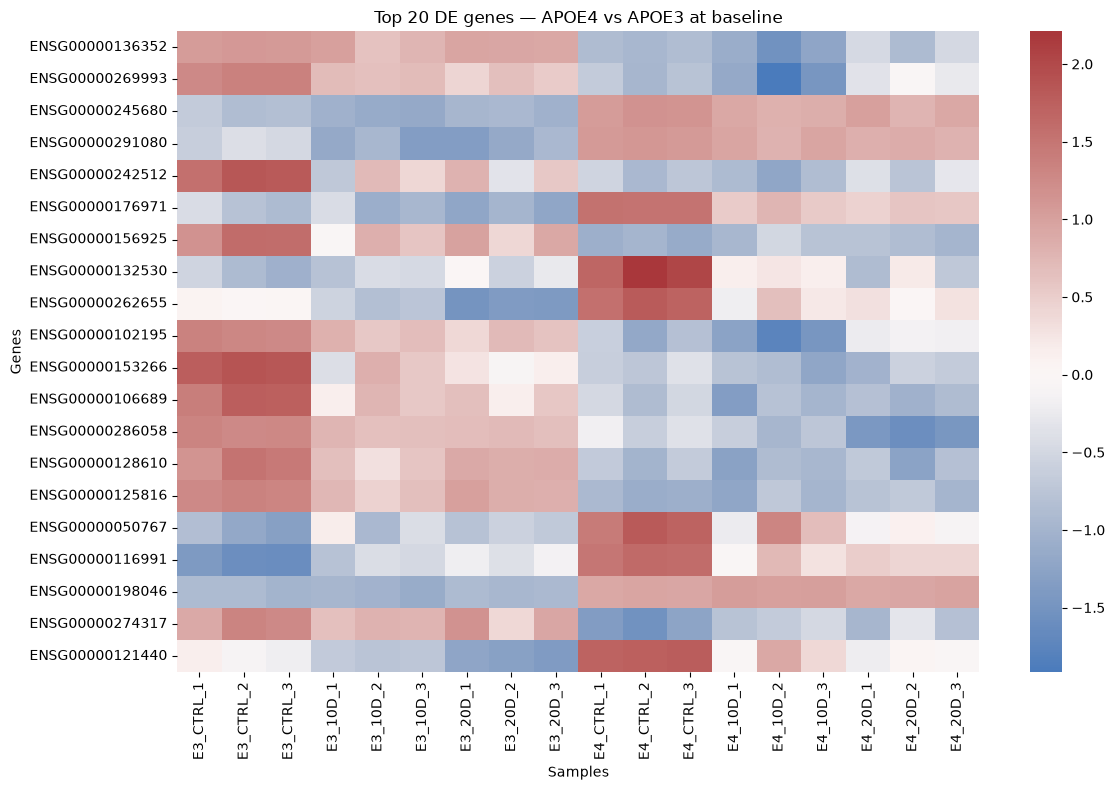

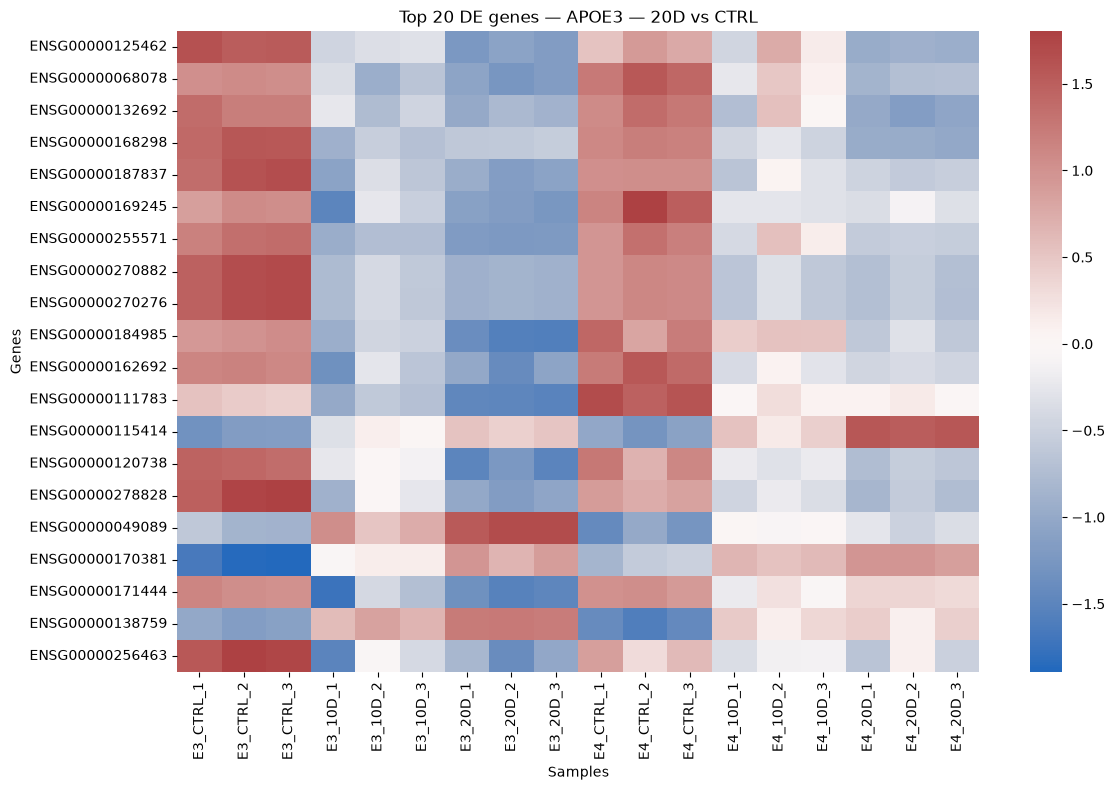

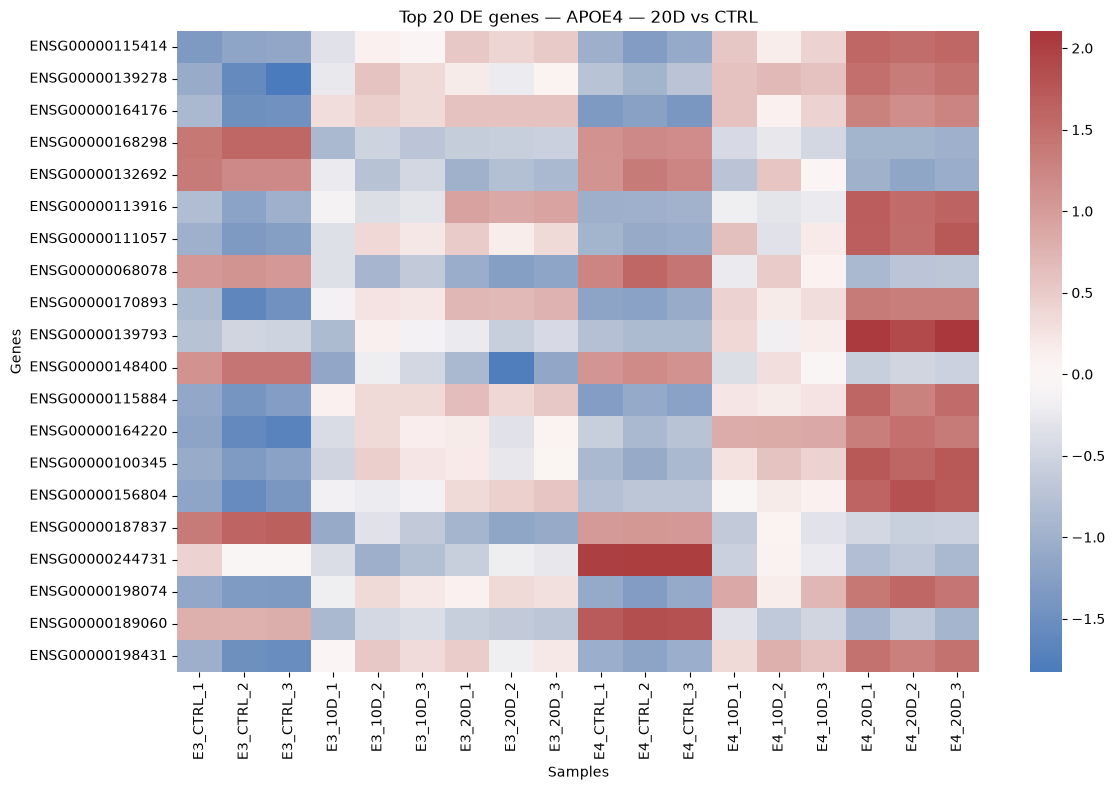

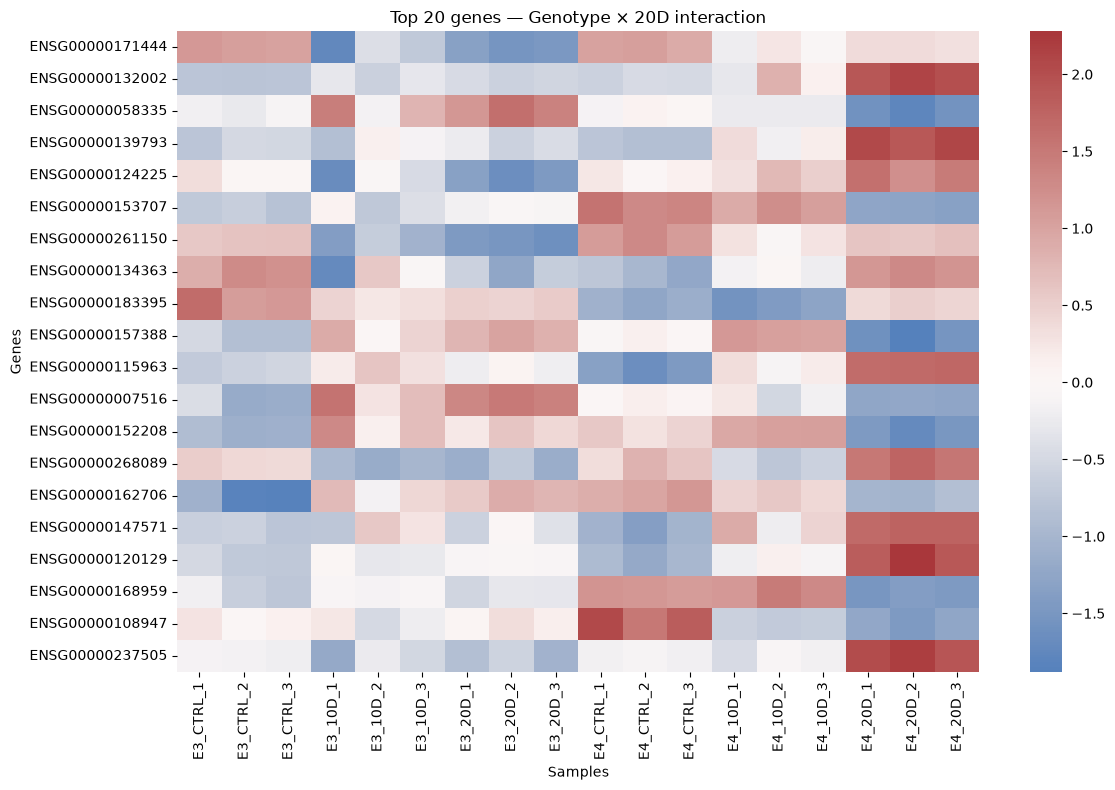

In [27]:
plot_top_genes_heatmap(
    ctrl_results,
    "Top 20 DE genes — APOE4 vs APOE3 at baseline"
)

plot_top_genes_heatmap(
    age_apoe3_results,
    "Top 20 DE genes — APOE3 — 20D vs CTRL"
)

plot_top_genes_heatmap(
    age_apoe4_results,
    "Top 20 DE genes — APOE4 — 20D vs CTRL"
)

plot_top_genes_heatmap(
    int_results,
    "Top 20 genes — Genotype × 20D interaction"
)

Heatmap interpretation

Baseline — APOE4 vs APOE3

* The top DE genes show clear differences between APOE3 and APOE4 at baseline. Several genes display consistently higher expression across the APOE3 CTRL replicates and lower expression across APOE4 CTRL replicates, while other genes show the opposite pattern. The consistency among the three biological replicates indicates that these genotype-associated expression patterns are reproducible within the groups.

APOE3 — 20D vs CTRL

* The top DE genes show substantial expression changes between CTRL and 20D samples in APOE3 organoids. Several genes display consistently higher expression after 20D treatment, while others show lower expression. The similar patterns across biological replicates indicate a consistent transcriptional response to 20D treatment in APOE3 organoids.

APOE4 — 20D vs CTRL

* The top DE genes also show substantial expression changes between CTRL and 20D samples in APOE4 organoids. Several genes show consistent changes across the three biological replicates, indicating a broad transcriptional response to 20D treatment. The expression patterns also differ from those observed in APOE3, supporting the presence of genotype-specific responses to 20D treatment.

Genotype × 20D interaction

* The interaction heatmap shows that several genes have expression patterns that change differently across APOE3 and APOE4 following 20D treatment. In particular, some genes show relatively similar expression between genotypes at baseline but diverge after 20D, while others show the opposite pattern. This is consistent with the DESeq2 interaction analysis indicating that the APOE4–APOE3 transcriptional difference changes after 20D treatment.

#### 5. GO annotations

Differential expression identifies individual genes, but the biological interpretation is more informative when these genes are considered as groups.

I therefore performed GO Biological Process enrichment separately for positive and negative DE genes for each comparison to identify biological processes represented among the transcriptional changes.

The background was restricted to the 29,414 genes retained after filtering.

In [28]:
def get_gene_lists(de_results):
    """
    Extract positive and negative DE gene lists
    without Ensembl version numbers.
    """

    positive = (
        de_results["up"]
        .index
        .str.replace(r"\..*$", "", regex=True)
        .tolist()
    )

    negative = (
        de_results["down"]
        .index
        .str.replace(r"\..*$", "", regex=True)
        .tolist()
    )

    return positive, negative

In [29]:
ctrl_up, ctrl_down = get_gene_lists(ctrl_results)
d20_apoe3_up, d20_apoe3_down = get_gene_lists(age_apoe3_results)
d20_apoe4_up, d20_apoe4_down = get_gene_lists(age_apoe4_results)
int_positive, int_negative = get_gene_lists(int_results)

In [30]:
print(len(ctrl_up), len(ctrl_down))
print(len(d20_apoe3_up), len(d20_apoe3_down))
print(len(d20_apoe4_up), len(d20_apoe4_down))
print(len(int_positive), len(int_negative))

1308 676
2310 2193
2501 2394
1778 1770


In [31]:
background_genes = (
    counts_deseq.columns
    .str.replace(r"\..*$", "", regex=True)
    .tolist()
)

print(len(background_genes))

29414


In [32]:
from gprofiler import GProfiler

gp = GProfiler(return_dataframe=True)

In [33]:
go_ctrl_up = gp.profile(
    organism="hsapiens",
    query=ctrl_up,
    background=background_genes,
    sources=["GO:BP"]
)

In [34]:
go_ctrl_up.head(10)

,source,native,name,p_value,significant,description,term_size,query_size,intersection_size,effective_domain_size,precision,recall,query,parents
0,GO:BP,GO:0032501,multicellular organismal process,1.877523e-22,True,"""Any biological process, occurring at the leve...",5893,1308,419,29412,0.320336,0.071101,query_1,[GO:0008150]
1,GO:BP,GO:0009605,response to external stimulus,3.858698e-22,True,"""Any process that results in a change in state...",1830,1308,183,29412,0.139908,0.100000,query_1,[GO:0050896]
2,GO:BP,GO:0051239,regulation of multicellular organismal process,9.693002e-21,True,"""Any process that modulates the frequency, rat...",2465,1308,220,29412,0.168196,0.089249,query_1,"[GO:0032501, GO:0050789]"
3,GO:BP,GO:0006952,defense response,2.892663e-20,True,"""Reactions, triggered in response to the prese...",1349,1308,146,29412,0.111621,0.108228,query_1,[GO:0006950]
4,GO:BP,GO:0042221,response to chemical,5.063901e-18,True,"""Any process that results in a change in state...",2926,1308,240,29412,0.183486,0.082023,query_1,[GO:0050896]
5,GO:BP,GO:0050896,response to stimulus,7.450577e-18,True,"""Any process that results in a change in state...",7035,1308,461,29412,0.352446,0.065529,query_1,[GO:0008150]
6,GO:BP,GO:0006955,immune response,7.725952e-18,True,"""Any immune system process that functions in t...",1298,1308,137,29412,0.104740,0.105547,query_1,"[GO:0002376, GO:0050896]"
7,GO:BP,GO:0002376,immune system process,4.734266e-16,True,"""Any process involved in the development or fu...",1995,1308,178,29412,0.136086,0.089223,query_1,[GO:0008150]
8,GO:BP,GO:0048513,animal organ development,2.176076e-15,True,"""Development of a tissue or tissues that work ...",2554,1308,210,29412,0.160550,0.082224,query_1,[GO:0048856]
9,GO:BP,GO:0032101,regulation of response to external stimulus,3.867184e-14,True,"""Any process that modulates the frequency, rat...",876,1308,99,29412,0.075688,0.113014,query_1,"[GO:0009605, GO:0048583]"


In [35]:
go_ctrl_up[[
    "name",
    "p_value",
    "intersection_size",
    "term_size"
]].head(30)

,name,p_value,intersection_size,term_size
0,multicellular organismal process,1.877523e-22,419,5893
1,response to external stimulus,3.858698e-22,183,1830
2,regulation of multicellular organismal process,9.693002e-21,220,2465
3,defense response,2.892663e-20,146,1349
4,response to chemical,5.063901e-18,240,2926
5,response to stimulus,7.450577e-18,461,7035
6,immune response,7.725952e-18,137,1298
7,immune system process,4.734266e-16,178,1995
8,animal organ development,2.176076e-15,210,2554
9,regulation of response to external stimulus,3.867184e-14,99,876


In [36]:
go_ctrl_down = gp.profile(
    organism="hsapiens",
    query=ctrl_down,
    background=background_genes,
    sources=["GO:BP"]
)

In [37]:
go_ctrl_down[[
    "name",
    "p_value",
    "intersection_size",
    "term_size"
]].head(30)

,name,p_value,intersection_size,term_size
0,chromosome segregation,1.229856e-34,68,410
1,nuclear division,7.091926e-34,67,407
2,chromosome organization,4.913173e-33,75,540
3,nuclear chromosome segregation,1.709311e-31,57,305
4,mitotic nuclear division,2.702597e-31,54,270
5,organelle fission,6.562660e-31,67,453
6,cell cycle process,3.339886e-29,105,1201
7,mitotic sister chromatid segregation,5.682605e-29,45,191
8,cell division,6.150736e-27,72,611
9,sister chromatid segregation,3.205788e-26,46,231


Baseline APOE genotype was associated with substantial transcriptional differences. APOE4-upregulated genes were enriched for immune and defense-related processes, including innate immune and cytokine responses, whereas APOE4-downregulated genes were strongly enriched for cell-cycle and mitotic processes, including chromosome segregation and nuclear division.

In [38]:
go_20d_up = gp.profile(
    organism="hsapiens",
    query=d20_apoe3_up,
    background=background_genes,
    sources=["GO:BP"]
)

In [39]:
go_20d_up[[
    "name",
    "p_value",
    "intersection_size",
    "term_size"
]].head(30)

,name,p_value,intersection_size,term_size
0,G protein-coupled receptor signaling pathway,2.329941e-07,106,709
1,neuropeptide signaling pathway,1.081335e-04,24,88
2,system process,2.365640e-04,186,1625
3,monocarboxylic acid transport,3.795769e-04,30,135
4,inflammatory response,4.363561e-04,89,649
5,extracellular matrix organization,6.046544e-04,47,272
6,external encapsulating structure organization,6.755624e-04,47,273
7,extracellular structure organization,6.755624e-04,47,273
8,organic acid transport,9.915981e-04,48,285
9,carboxylic acid transport,9.915981e-04,48,285


In [40]:
go_20d_down = gp.profile(
    organism="hsapiens",
    query=d20_apoe3_down,
    background=background_genes,
    sources=["GO:BP"]
)

In [41]:
go_20d_down[[
    "name",
    "p_value",
    "intersection_size",
    "term_size"
]].head(30)

,name,p_value,intersection_size,term_size
0,nucleosome assembly,1.071337e-29,52,97
1,animal organ development,2.044097e-29,356,2554
2,chromosome organization,1.151480e-25,122,540
3,nucleosome organization,5.164912e-25,52,115
4,mitotic cell cycle,1.820989e-24,160,855
5,mitotic cell cycle process,2.021419e-24,143,718
6,anatomical structure development,4.844938e-24,575,5109
7,cell cycle process,6.554084e-24,199,1201
8,multicellular organism development,1.583244e-23,488,4154
9,cell differentiation,3.963314e-23,448,3731


In [42]:
go_20d_apoe4_up = gp.profile(
    organism="hsapiens",
    query=d20_apoe4_up,
    background=background_genes,
    sources=["GO:BP"]
)

In [43]:
go_20d_apoe4_up[[
    "name",
    "p_value",
    "intersection_size",
    "term_size"
]].head(30)

,name,p_value,intersection_size,term_size
0,tissue development,1.007323e-23,274,1675
1,positive regulation of multicellular organisma...,3.887964e-22,234,1376
2,cell population proliferation,6.957831e-22,268,1669
3,regulation of cell population proliferation,1.363820e-20,230,1378
4,regulation of multicellular organismal process,1.575295e-20,353,2465
5,multicellular organismal process,5.393524e-20,698,5893
6,cell adhesion,1.319129e-19,213,1259
7,cell activation,1.197209e-17,161,879
8,anatomical structure formation involved in mor...,4.457675e-17,176,1011
9,response to external stimulus,2.200372e-16,269,1830


In [44]:
go_20d_apoe4_down = gp.profile(
    organism="hsapiens",
    query=d20_apoe4_down,
    background=background_genes,
    sources=["GO:BP"]
)

In [45]:
go_20d_apoe4_down[[
    "name",
    "p_value",
    "intersection_size",
    "term_size"
]].head(30)

,name,p_value,intersection_size,term_size
0,cilium movement,7.173153e-17,64,217
1,axoneme assembly,1.883711e-13,38,99
2,microtubule bundle formation,7.819899e-13,43,129
3,cilium or flagellum-dependent cell motility,8.293898e-12,50,178
4,cilium-dependent cell motility,8.293898e-12,50,178
5,cilium movement involved in cell motility,1.793613e-11,49,175
6,nucleosome assembly,2.845964e-11,35,97
7,flagellated sperm motility,8.801545e-11,45,157
8,sperm motility,8.801545e-11,45,157
9,negative regulation of viral genome replication,4.817621e-10,22,43


In [46]:
go_int_positive = gp.profile(
    organism="hsapiens",
    query=int_positive,
    background=background_genes,
    sources=["GO:BP"]
)

In [47]:
go_int_positive[[
    "name",
    "p_value",
    "intersection_size",
    "term_size"
]].head(30)

,name,p_value,intersection_size,term_size
0,cell population proliferation,3.026370e-54,280,1669
1,regulation of biological process,1.495867e-49,896,9807
2,anatomical structure development,8.542479e-48,560,5109
3,biological regulation,1.408783e-47,911,10129
4,regulation of cellular process,3.432656e-46,863,9463
5,negative regulation of biological process,1.499544e-45,519,4655
6,tissue development,1.960463e-45,264,1675
7,regulation of cell population proliferation,2.410064e-45,234,1378
8,developmental process,5.466946e-45,586,5557
9,cell differentiation,6.620619e-45,444,3731


In [48]:
go_int_negative = gp.profile(
    organism="hsapiens",
    query=int_negative,
    background=background_genes,
    sources=["GO:BP"]
)

In [49]:
go_int_negative[[
    "name",
    "p_value",
    "intersection_size",
    "term_size"
]].head(30)

,name,p_value,intersection_size,term_size
0,sensory perception of chemical stimulus,0.000080,24,110
1,trans-synaptic signaling,0.000896,78,718
2,anterograde trans-synaptic signaling,0.001202,77,711
3,chemical synaptic transmission,0.001202,77,711
4,synaptic signaling,0.001780,79,743
5,detection of chemical stimulus,0.002240,21,104
6,detection of chemical stimulus involved in sen...,0.003047,17,73
7,detection of chemical stimulus involved in sen...,0.004061,13,45
8,sensory perception of smell,0.005400,16,68
9,modulation of chemical synaptic transmission,0.042225,52,468


**Results**

* At baseline, APOE4 and APOE3 organoids showed clear differences in gene expression. APOE4-upregulated genes were enriched for immune and defense-related processes, including innate immune and cytokine responses, whereas APOE4-downregulated genes were enriched for cell-cycle and mitotic processes, including chromosome segregation and nuclear division.
* After 20 days of treatment, APOE3 organoids showed enrichment among upregulated genes for GPCR and neuropeptide signaling, metabolite transport, extracellular matrix organization, cell-cell signaling, and immune/defense responses. Downregulated genes were strongly enriched for nucleosome and chromosome organization, mitotic cell cycle, chromosome segregation, cell division, and developmental processes.
* In APOE4 organoids, upregulated genes after 20D were strongly enriched for cell population proliferation, tissue and anatomical development, cell differentiation, mitotic cell-cycle processes, and cellular responses to stimuli. Downregulated genes were mainly enriched for cilium movement, axoneme assembly, microtubule-based movement, cilium organization, nucleosome organization, and viral-response processes.
* The genotype × 20D interaction showed that the APOE4–APOE3 transcriptional difference changed following 20D treatment. Positive interaction effects were enriched for cell population proliferation, tissue and anatomical development, cell differentiation, and cell-cycle processes. Negative interaction effects were enriched for sensory perception, chemical stimulus detection, and synaptic/trans-synaptic signaling.

**Interpretation**

* APOE4 organoids showed a distinct baseline transcriptional state compared with APOE3, with enrichment of immune and defense-related programs and differences in cell-cycle and mitotic processes.
* 20D treatment induced substantial transcriptional remodeling in both genotypes, but the enriched biological processes differed. In APOE3, the response involved signaling, transport, extracellular organization, immune/defense responses, and chromatin/cell-cycle programs. In APOE4, the response prominently involved developmental, proliferative, differentiation, and cell-cycle programs, together with changes in ciliary and microtubule-associated processes.
* The genotype × 20D interaction indicates that the response to 20D is not identical between APOE3 and APOE4. Instead, 20D changes the transcriptional difference between the two genotypes, with genotype-dependent effects involving developmental and proliferative programs as well as sensory and synaptic signaling.
  
**Interpretation in the context of bulk organoids**

* Because the analysis is based on bulk RNA-seq, enrichment of processes such as proliferation, differentiation, immune response, or neuronal signaling may reflect changes in the transcriptional state of cells, differences in cellular composition, or both. Therefore, these results identify transcriptional programs associated with the experimental conditions but do not by themselves establish cell-type-specific mechanisms.


**Biological context**

* The observed APOE4-associated immune and defense programs, as well as genotype-dependent changes in sensory and synaptic signaling, are consistent with previous studies reporting isoform-dependent effects of APOE4 on inflammatory responses and neuronal/synaptic phenotypes. APOE4 has also been associated with altered lipid and cholesterol homeostasis in human brain and organoid models. However, these processes were not necessarily enriched in the present dataset, and therefore were not used as primary interpretations of the current results.

**Limitations**

* The main experimental limitation is that the 10D treatment is completely confounded with harvest day: 10D samples were harvested at day 70, whereas CTRL and 20D samples were harvested at day 80. Therefore, differences involving 10D cannot be attributed exclusively to the ageing treatment.

* For this reason, the genotype × treatment interaction analysis was restricted to CTRL and 20D samples, which were both harvested at day 80. In addition, the study contains three biological replicates per group, so results should be interpreted as exploratory and validated in larger independent experiments.

* Because the dataset consists of bulk RNA-seq from brain organoids, the analysis cannot distinguish cell-intrinsic transcriptional changes from changes in the relative abundance of different cell populations within the organoids. Cell-type-resolved data would be required to determine which populations drive the observed transcriptional differences.
  
* Circular RNA analysis: Circular RNA analysis was not performed because the supplied data consisted of gene-level count matrices and therefore did not provide the back-splice junction information required for reliable circRNA detection and quantification.

**Conclusion**

This analysis identified substantial transcriptional differences between APOE3 and APOE4 brain organoids and broad transcriptional responses to 20D treatment.

At baseline, APOE4-associated differences were characterized mainly by immune/defense and cell-cycle-related programs. Both genotypes showed extensive transcriptional remodeling following 20D treatment, but the enriched biological processes differed between APOE3 and APOE4.

Importantly, the genotype × 20D interaction demonstrated that the transcriptional response to 20D differs between the two APOE genotypes, with genotype-dependent changes involving developmental/proliferative and sensory/synaptic programs.

Overall, the results indicate that APOE genotype is associated with distinct transcriptional states and modifies the transcriptional response to 20D treatment in human brain organoids.

#### References

1. Conesa A, Madrigal P, Tarazona S, et al. (2016). A survey of best practices for RNA-seq data analysis. *Genome Biology*, 17, 13.

2. Love MI, Huber W, Anders S. (2014). Moderated estimation of fold change and dispersion for RNA-seq data with DESeq2. *Genome Biology*, 15, 550.

3. Raudvere U, Kolberg L, Kuzmin I, et al. (2019). g:Profiler: a web server for functional enrichment analysis and conversions of gene lists. *Nucleic Acids Research*, 47(W1), W191–W198.

4. Zhao J, Fu Y, Yamazaki Y, et al. (2020). APOE4 exacerbates synapse loss and neurodegeneration in Alzheimer's disease patient iPSC-derived cerebral organoids. *Nature Communications*, 11, 5540.

5. Lisowski P, Lickfett S, Rybak-Wolf A, et al. (2024). Mutant Huntingtin impairs neurodevelopment in human brain organoids through CHCHD2-mediated neurometabolic failure. *Nature Communications*, 15, 7027.
